# Aufgabe 1

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.filters import gaussian, laplace, sobel
from skimage.util import img_as_float, random_noise

## 1.1

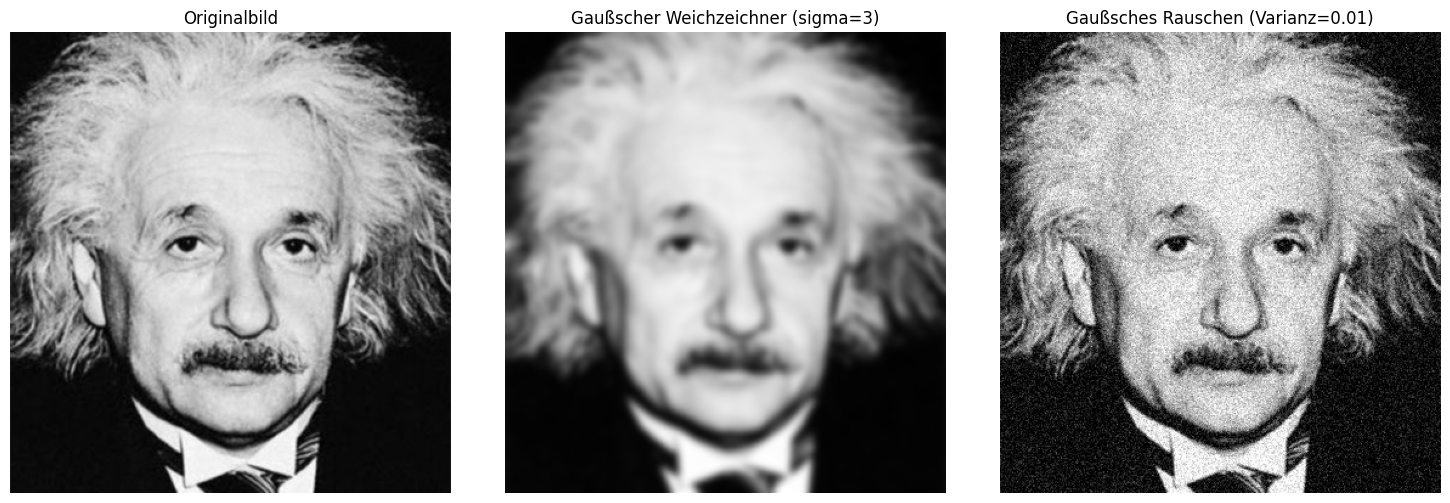

In [27]:
# Einstein Bild laden
img_original = imread("einstein.png")

# bild im bereich [0, 1] bringen
img = img_as_float(img_original)

# Gaußscher Weichzeichner mit sigma=3
img_gaussian = gaussian(img, sigma=3)

# Gaußsches Rauschen mit Varianz 0.01
img_noisy = random_noise(img, mode='gaussian', var=0.01)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Originalbild")
axes[0].axis('off')

axes[1].imshow(img_gaussian, cmap='gray')
axes[1].set_title("Gaußscher Weichzeichner (sigma=3)")
axes[1].axis('off')

axes[2].imshow(img_noisy, cmap='gray')
axes[2].set_title("Gaußsches Rauschen (Varianz=0.01)")
axes[2].axis('off')

plt.tight_layout()
plt.show()


## 1.2

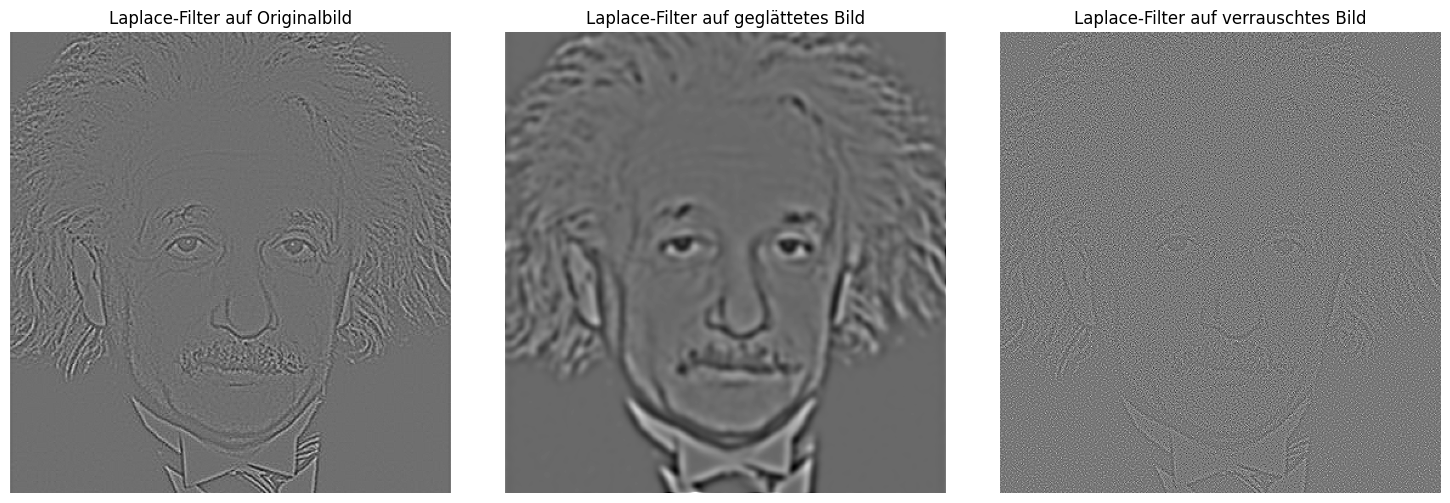

In [28]:
# Laplace-Filter auf alle drei Bilder anwenden
img_laplace_original = laplace(img)
img_laplace_gaussian = laplace(img_gaussian)
img_laplace_noisy = laplace(img_noisy)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_laplace_original, cmap='gray')
axes[0].set_title("Laplace-Filter auf Originalbild")
axes[0].axis('off')

axes[1].imshow(img_laplace_gaussian, cmap='gray')
axes[1].set_title("Laplace-Filter auf geglättetes Bild")
axes[1].axis('off')

axes[2].imshow(img_laplace_noisy, cmap='gray')
axes[2].set_title("Laplace-Filter auf verrauschtes Bild")
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Beobachtungen zum Laplace-Filter

**Laplace auf Originalbild:** Der Filter hebt die Kanten deutlich hervor und erzeugt ein klares Kantendetektor-Bild.

**Laplace auf geglättetes Bild:** Weniger detaillierten Kanten.

**Laplace auf verrauschtes Bild:** Das Rauschen wird vom Laplace-Filter als zusätzliche Kanten interpretiert, daher sind die echten Kanten zu schwach dargestellt und andere Stellen sind fälschlicherweise hervorgehoben.

## 1.3

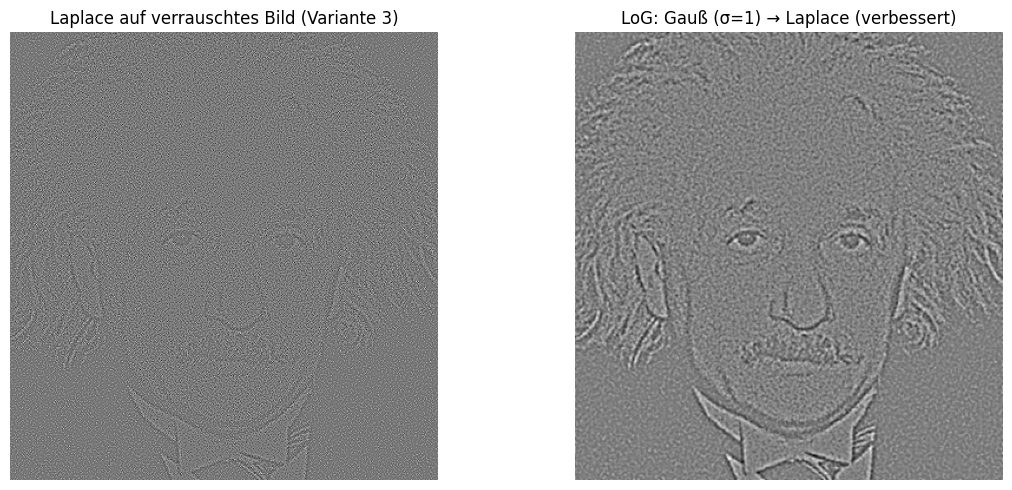

In [29]:
# Verbesserungsvorschlag: Laplacian of Gaussian
# Vor der Kantenextraktion wird das verrauschte Bild mit einem Gaußfilter (σ=1) geglättet,
# um hochfrequentes Rauschen zu dämpfen, bevor Laplace es verstärkt.
img_noisy_smoothed = gaussian(img_noisy, sigma=1)
img_laplace_noisy_improved = laplace(img_noisy_smoothed)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_laplace_noisy, cmap='gray')
axes[0].set_title("Laplace auf verrauschtes Bild (Variante 3)")
axes[0].axis('off')

axes[1].imshow(img_laplace_noisy_improved, cmap='gray')
axes[1].set_title("LoG: Gauß (σ=1) → Laplace (verbessert)")
axes[1].axis('off')

plt.tight_layout()
plt.show()


### Begründung: Gaußglättung vor dem Laplace-Filter (LoG)

Der Laplace-Filter verstärkt hochfrequente Anteile – sowohl Kanten als auch Rauschen. Der vorgeschaltete Gaußfilter (σ=1) dämpft das hochfrequente Rauschen, sodass Laplace danach hauptsächlich echte Kanten hervorhebt. Im Vergleich zu Variante 3 sind die Kanten im LoG-Bild deutlich klarer.

## 1.4

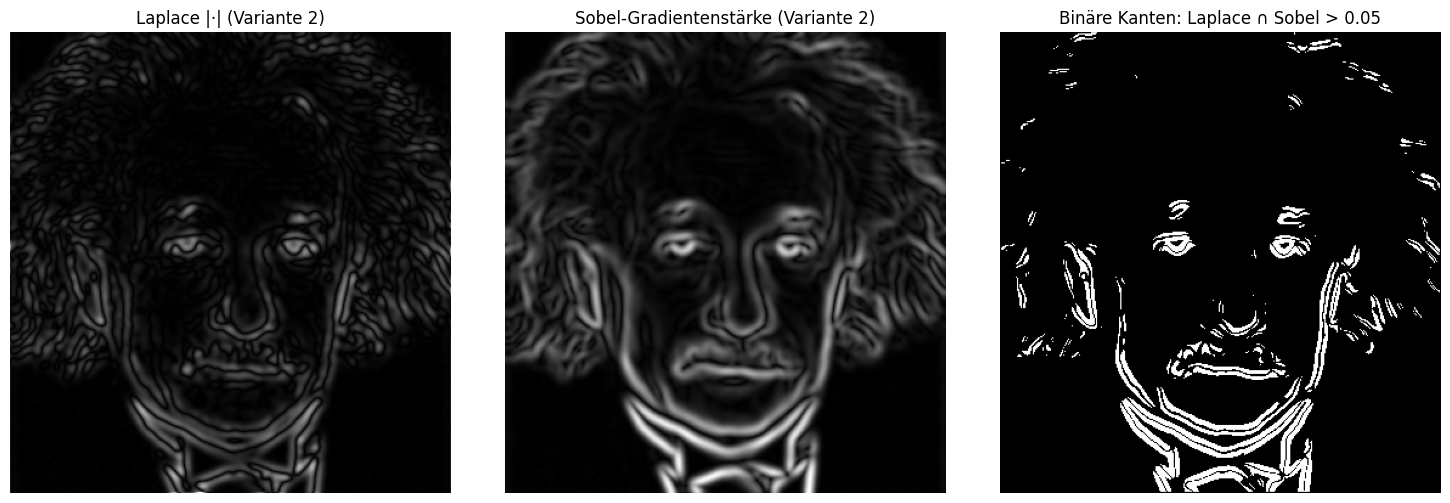

In [30]:
# Sobel-Gradientenstärke auf dem geglätteten Bild (Variante 2) berechnen
img_sobel_gaussian = sobel(img_gaussian)

# Schwellenwert für die Sobel-Gradientenstärke (kann angepasst werden)
threshold = 0.05

# Schritt 1: Kantenkandidaten aus dem Laplace-Ergebnis (Variante 2) – alle Pixel mit |Laplace| > epsilon
laplace_edges = np.abs(img_laplace_gaussian) > 0.005

# Randpixel ignorieren (gemäß Aufgabenhinweis)
laplace_edges[0, :]  = False
laplace_edges[-1, :] = False
laplace_edges[:, 0]  = False
laplace_edges[:, -1] = False

# Schritt 2: Schwache Kanten (geringe Sobel-Gradientenstärke) aussortieren
# Kantenpixel = 1, alle anderen = 0
edges_binary = (laplace_edges & (img_sobel_gaussian > threshold)).astype(np.float64)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(np.abs(img_laplace_gaussian), cmap='gray')
axes[0].set_title("Laplace |·| (Variante 2)")
axes[0].axis('off')

axes[1].imshow(img_sobel_gaussian, cmap='gray')
axes[1].set_title("Sobel-Gradientenstärke (Variante 2)")
axes[1].axis('off')

axes[2].imshow(edges_binary, cmap='gray')
axes[2].set_title(f"Binäre Kanten: Laplace ∩ Sobel > {threshold}")
axes[2].axis('off')

plt.tight_layout()
plt.show()


Die wichtigsten Kantenpixel werden nicht erkannt. Das ist an den schwarzen Strichen innerhalb der weißen Bereiche zu erkennen.

## 1.5


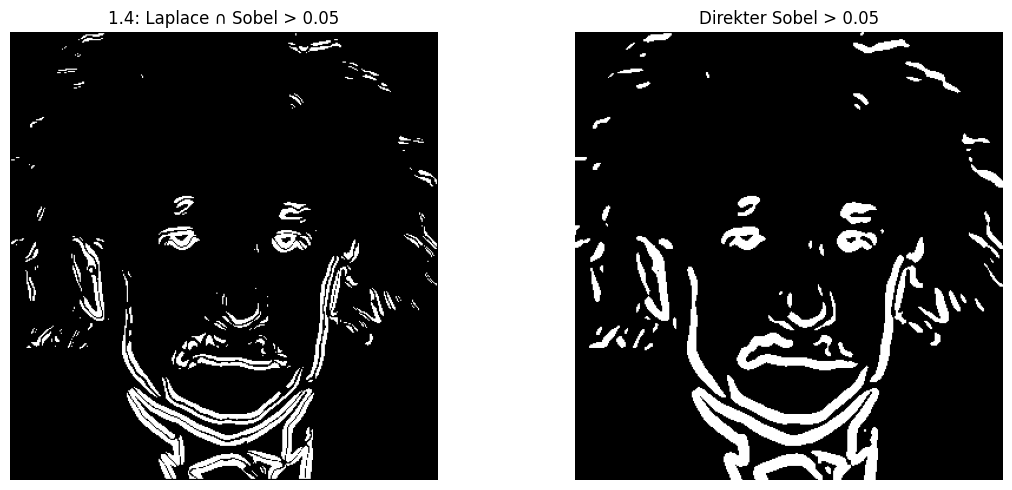

In [31]:
# Direkter Sobel-Filter auf Variante 2 – binärisiert mit gleichem Schwellenwert
edges_sobel_only = (img_sobel_gaussian > threshold).astype(np.float64)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(edges_binary, cmap='gray')
axes[0].set_title(f"1.4: Laplace ∩ Sobel > {threshold}")
axes[0].axis('off')

axes[1].imshow(edges_sobel_only, cmap='gray')
axes[1].set_title(f"Direkter Sobel > {threshold}")
axes[1].axis('off')

plt.tight_layout()
plt.show()


Der direkte Sobel erkennt auch die innen liegenden Kantenpixel (die wahren Kanten). Jedoch sind auch hier die weißen Bereiche sehr breit.